# 03 – Baseline CNN
Enkel CNN trent fra scratch på mel-spektrogrammer. Oppfyller mandatory-kravet.

In [2]:
# ============================================================
# 03_baseline_cnn.ipynb  –  Mandatory CNN fra scratch
# ============================================================

# --- 1. Importer og seed ---
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle, json
from pathlib import Path
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# --- 2. Monter Drive og stier ---
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

PROCESSED = Path("/content/drive/MyDrive/processed")
print("Filer:", [f.name for f in PROCESSED.iterdir()])

Mounted at /content/drive
Filer: ['X_val.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', 'label_encoder.pkl', 'X_test.npy', 'X_train.npy']


In [4]:
# --- 3. Last inn data ---
X_train = np.load(PROCESSED / "X_train.npy")
y_train = np.load(PROCESSED / "y_train.npy")
X_val   = np.load(PROCESSED / "X_val.npy")
y_val   = np.load(PROCESSED / "y_val.npy")
X_test  = np.load(PROCESSED / "X_test.npy")
y_test  = np.load(PROCESSED / "y_test.npy")

with open(PROCESSED / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
INPUT_SHAPE = X_train.shape[1:]

print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"Input shape   : {INPUT_SHAPE}")
print(f"Klasser ({NUM_CLASSES}): {list(le.classes_)}")

X_train shape : (4695, 128, 130, 1)
X_val shape   : (1004, 128, 130, 1)
X_test shape  : (1006, 128, 130, 1)
Input shape   : (128, 130, 1)
Klasser (11): [np.str_('cel'), np.str_('cla'), np.str_('flu'), np.str_('gac'), np.str_('gel'), np.str_('org'), np.str_('pia'), np.str_('sax'), np.str_('tru'), np.str_('vio'), np.str_('voi')]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
# --- 4. Bygg baseline CNN ---
def build_baseline_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          kernel_initializer='he_uniform')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding='same',
                      kernel_initializer='he_uniform')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="baseline_cnn")

model = build_baseline_cnn(INPUT_SHAPE, NUM_CLASSES)
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 130, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,587 (1.50 MB)

 Trainable params: 391,627 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# --- 5. Kompiler ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# --- 6. Callbacks ---
CHECKPOINT_PATH = str(PROCESSED / "baseline_best.keras")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

In [8]:
# --- 7. Tren modellen ---
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2413 - loss: 2.1942
Epoch 1: val_loss improved from None to 3.17524, saving model to /content/drive/MyDrive/processed/baseline_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/processed/baseline_best.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - accuracy: 0.3001 - loss: 2.0406 - val_accuracy: 0.1653 - val_loss: 3.1752 - learning_rate: 0.0010
Epoch 2/100
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3788 - loss: 1.8064
Epoch 2: val_loss did not improve from 3.17524
147/147 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4166 - loss: 1.7163 - val_accuracy: 0.1534 - val_loss: 3.7471 - learning_rate: 0.0010
Epoch 3/100
145/147 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4611 - loss: 1.5972
Epoch 3: val_loss improved from 3.17524 to 2.93476, saving model to /content/drive/MyDrive/processed/baseline_best.keras

Epoch 3: finished saving model to /content/drive/MyDrive/processed/baseline_

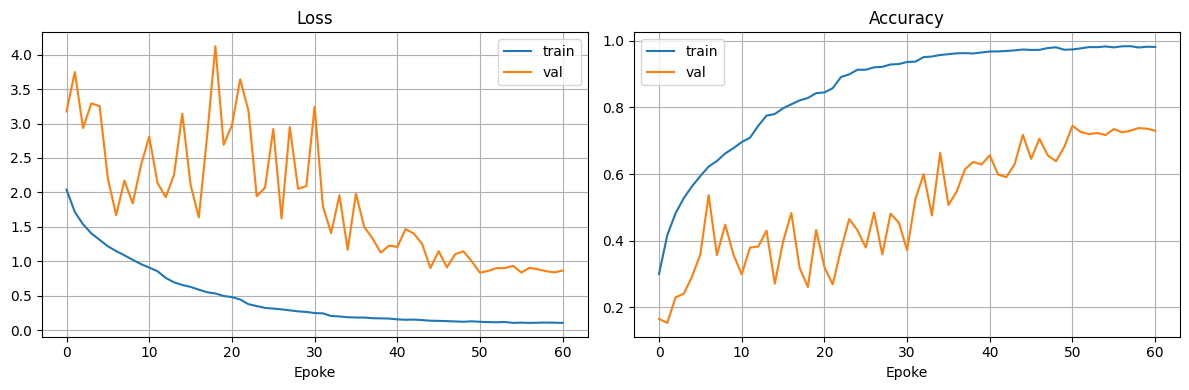

In [9]:
# --- 8. Treningskurver ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'],     label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoke')
ax1.legend(); ax1.grid(True)

ax2.plot(history.history['accuracy'],     label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoke')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(PROCESSED / "baseline_training_curves.png", dpi=150)
plt.show()

In [10]:
# --- 9. Evaluer på testsettet ---
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


Test loss    : 0.9246
Test accuracy: 0.7286


In [11]:
# --- 10. Classification report ---
y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

Classification Report:
              precision    recall  f1-score   support

         cel       0.78      0.55      0.65        58
         cla       0.58      0.70      0.63        76
         flu       0.77      0.53      0.63        68
         gac       0.80      0.80      0.80        96
         gel       0.62      0.68      0.65       114
         org       0.76      0.87      0.81       102
         pia       0.76      0.94      0.84       108
         sax       0.53      0.61      0.57        94
         tru       0.82      0.76      0.79        86
         vio       0.76      0.55      0.64        87
         voi       0.92      0.82      0.87       117

    accuracy                           0.73      1006
   macro avg       0.74      0.71      0.72      1006
weighted avg       0.74      0.73      0.73      1006



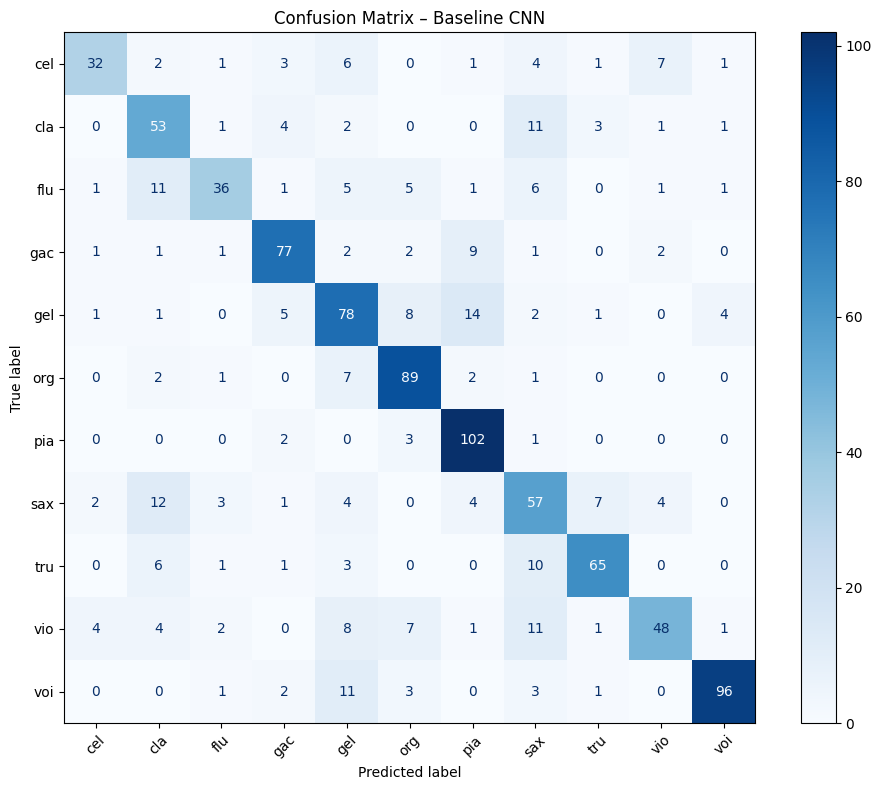

In [12]:
# --- 11. Confusion matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=le.classes_,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title("Confusion Matrix – Baseline CNN")
plt.tight_layout()
plt.savefig(PROCESSED / "baseline_confusion_matrix.png", dpi=150)
plt.show()

In [13]:
# --- 12. Dummy baseline ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train.reshape(len(X_train), -1), y_train)
dummy_acc = dummy.score(X_test.reshape(len(X_test), -1), y_test)

print(f"Dummy classifier accuracy : {dummy_acc:.4f}")
print(f"Baseline CNN accuracy     : {test_acc:.4f}")
print(f"Forbedring over dummy     : +{(test_acc - dummy_acc)*100:.1f} prosentpoeng")

Dummy classifier accuracy : 0.1163
Baseline CNN accuracy     : 0.7286
Forbedring over dummy     : +61.2 prosentpoeng


In [14]:
# --- 13. Lagre resultater ---
resultater = {
    "test_loss":      float(test_loss),
    "test_accuracy":  float(test_acc),
    "dummy_accuracy": float(dummy_acc),
    "epoker_trent":   len(history.history['loss']),
    "klasser":        list(le.classes_)
}

with open(PROCESSED / "baseline_resultater.json", "w") as f:
    json.dump(resultater, f, indent=2)

print("Resultater lagret!")
print(json.dumps(resultater, indent=2))

Resultater lagret!
{
  "test_loss": 0.9246460199356079,
  "test_accuracy": 0.7286282181739807,
  "dummy_accuracy": 0.11630218687872763,
  "epoker_trent": 61,
  "klasser": [
    "cel",
    "cla",
    "flu",
    "gac",
    "gel",
    "org",
    "pia",
    "sax",
    "tru",
    "vio",
    "voi"
  ]
}
